<a href="https://colab.research.google.com/github/tu26010-7431-hue/Tu26010/blob/main/Chap05_Ex_01~18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import numpy as np
import numpy.random as random
import scipy as sp
import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline
%precision 3

'%.3f'

In [37]:
# 5-1
sample_names = np.array(['a','b','c','d','a'])
random.seed(0)
data = random.randn(5,5)

print(sample_names)
print(data)

data[sample_names == 'b']

['a' 'b' 'c' 'd' 'a']
[[ 1.764  0.4    0.979  2.241  1.868]
 [-0.977  0.95  -0.151 -0.103  0.411]
 [ 0.144  1.454  0.761  0.122  0.444]
 [ 0.334  1.494 -0.205  0.313 -0.854]
 [-2.553  0.654  0.864 -0.742  2.27 ]]


array([[-0.977,  0.95 , -0.151, -0.103,  0.411]])

In [38]:
# 5-2
data[sample_names != 'c']

array([[ 1.764,  0.4  ,  0.979,  2.241,  1.868],
       [-0.977,  0.95 , -0.151, -0.103,  0.411],
       [ 0.334,  1.494, -0.205,  0.313, -0.854],
       [-2.553,  0.654,  0.864, -0.742,  2.27 ]])

In [39]:
# 5-3
x_array = np.array([1,2,3,4,5])
y_array = np.array([6,7,8,9,10])

cond_data = np.array([False,False,True,True,False])
print(np.where(cond_data,x_array,y_array))

[ 6  7  3  4 10]


In [40]:
# 5-4
sample_multi_array_data2 = np.arange(16).reshape(4,4)
sample_multi_array_data2

np.sqrt(sample_multi_array_data2)

array([[0.   , 1.   , 1.414, 1.732],
       [2.   , 2.236, 2.449, 2.646],
       [2.828, 3.   , 3.162, 3.317],
       [3.464, 3.606, 3.742, 3.873]])

In [41]:
# 5-5
print('最大値',sample_multi_array_data2.max())
print('最小値',sample_multi_array_data2.min())
print('合計',sample_multi_array_data2.sum())
print('平均',sample_multi_array_data2.mean())

最大値 15
最小値 0
合計 120
平均 7.5


In [42]:
# 5-6
print("対角成分の和",np.trace(sample_multi_array_data2))

対角成分の和 30


In [43]:
# 5-7
sample_array1 = np.arange(12).reshape(3,4)
sample_array2 = np.arange(12).reshape(3,4)

np.concatenate([sample_array1,sample_array2])

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [44]:
# 5-8
np.concatenate([sample_array1,sample_array2],axis=1)

array([[ 0,  1,  2,  3,  0,  1,  2,  3],
       [ 4,  5,  6,  7,  4,  5,  6,  7],
       [ 8,  9, 10, 11,  8,  9, 10, 11]])

In [45]:
# 5-9
sample_list = [1,2,3,4,5]
np.array(sample_list)+3

array([4, 5, 6, 7, 8])

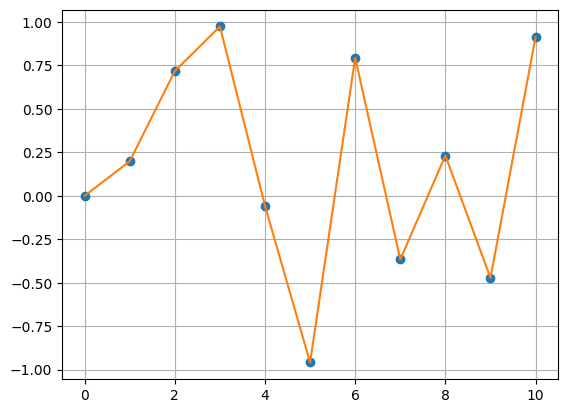

In [46]:
# 5-10
x = np.linspace(0,10,num=11,endpoint=True)
y = np.sin(x**2/5.0)
plt.plot(x,y,'o')
plt.grid(True)

from scipy import interpolate
f = interpolate.interp1d(x,y,'linear')
plt.plot(x,f(x),'-')
plt.grid(True)

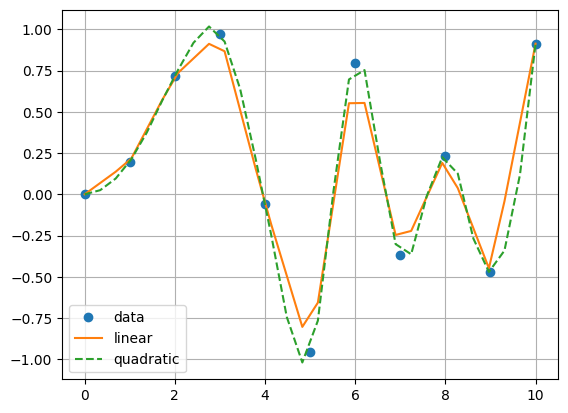

In [47]:
# 5-11
f2 = interpolate.interp1d(x,y,'quadratic')
xnew = np.linspace(0,10,num=30,endpoint=True)
plt.plot(x,y,'o',xnew,f(xnew),'-',xnew,f2(xnew),'--')
plt.legend(['data','linear','quadratic'],loc = 'best')
plt.grid(True)

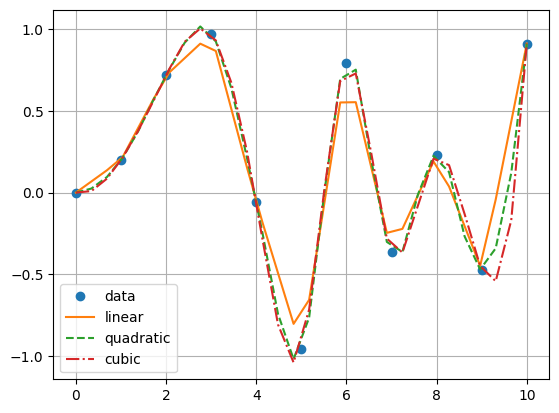

In [48]:
# 5-12
f2 = interpolate.interp1d(x,y,'quadratic')
f3 = interpolate.interp1d(x,y,'cubic')
xnew = np.linspace(0,10,num=30,endpoint=True)
plt.plot(x,y,'o',xnew,f(xnew),'-',xnew,f2(xnew),'--',xnew,f3(xnew),'-.')
plt.legend(['data','linear','quadratic','cubic'],loc = 'best')
plt.grid(True)

In [49]:
# 5-13
B = np.array([[1,2,3],[4,5,6],[7,8,9],[10,11,12]])

U,s,Vs = sp.linalg.svd(B)
m,n = B.shape
S = sp.linalg.diagsvd(s,m,n)

print('U,S,V* = \n',U@S@Vs)

U,S,V* = 
 [[ 1.  2.  3.]
 [ 4.  5.  6.]
 [ 7.  8.  9.]
 [10. 11. 12.]]


In [50]:
# 5-14
A = np.identity(3)
print(A)
A[0,:] = 1
A[:,0] = 1
A[0,0] = 3
b = np.ones(3)

(LU,piv) = sp.linalg.lu_factor(A)
L = np.identity(3) + np.tril(LU,-1)
U = np.triu(LU)
P = np.identity(3)[piv]
sp.linalg.lu_solve((LU,piv),b)

[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


array([-1.,  2.,  2.])

In [51]:
np.dot(A,sp.linalg.lu_solve((LU,piv),b))

array([1., 1., 1.])

In [52]:
# 5-15
from scipy import integrate
def calcl(x):
  return (x+1)**2
integrate.quad(calcl,0,2)

(8.667, 0.000)

In [53]:
# 5-16
import math
from numpy import cos
from scipy import integrate

integrate.quad(cos,0,math.pi/1)

(0.000, 0.000)

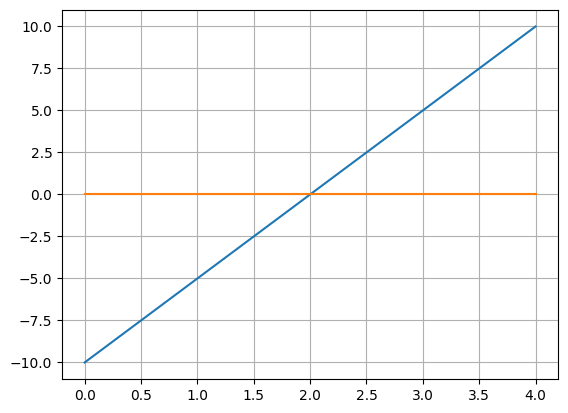

In [54]:
# 5-17
def f(x):
  y = 5*x-10
  return y
x = np.linspace(0,4)
plt.plot(x,f(x))
plt.plot(x,np.zeros(len(x)))
plt.grid(True)

In [55]:
from scipy.optimize import fsolve
x = fsolve(f,2)
print(x)

[2.]


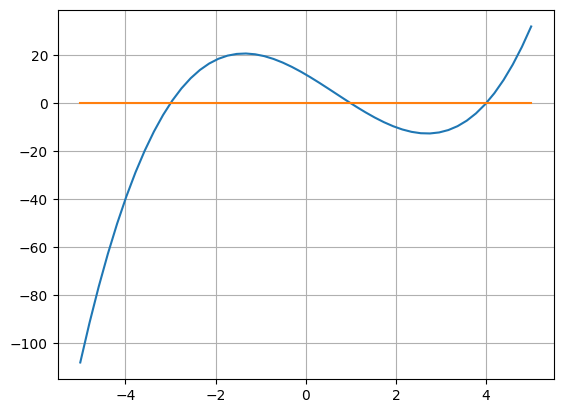

In [56]:
# 5-18
def f2(x):
  y = x**3-2*x**2-11*x+12
  return y
x= np.linspace(-5,5)
plt.plot(x,f2(x))
plt.plot(x,np.zeros(len(x)))
plt.grid(True)

In [57]:
x = fsolve(f2,1)
print(x)

[1.]


In [58]:
x = fsolve(f2,4)
print(x)

[4.]
